# Social Media Engagement Analysis — Q4 2025

A 90-day cross-platform analysis of social media performance across Instagram, YouTube, Twitter/X, and TikTok.

**Goal:** Clean raw engagement data, calculate key performance metrics, and identify actionable trends across platforms.

**Tools:** Python, Pandas, NumPy, Matplotlib

**Author:** Jayasree


## 1. Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("data/social_engagement_data.csv", parse_dates=["date"])
df.head()

,date,platform,impressions,likes,comments,shares,new_followers,engagement,engagement_rate
0,2025-10-01,Instagram,4160,146,9,18,16,173,0.041587
1,2025-10-01,YouTube,2483,72,5,15,15,92,0.037052
2,2025-10-01,Twitter/X,1733,24,3,4,0,31,0.017888
3,2025-10-01,TikTok,3506,171,23,32,18,226,0.064461
4,2025-10-02,Instagram,3246,110,10,16,23,136,0.041898


In [2]:
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Platforms: {df['platform'].unique().tolist()}")
df.info()

Shape: (360, 9)
Date range: 2025-10-01 to 2025-12-29
Platforms: ['Instagram', 'YouTube', 'Twitter/X', 'TikTok']
<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             360 non-null    datetime64[us]
 1   platform         360 non-null    str           
 2   impressions      360 non-null    int64         
 3   likes            360 non-null    int64         
 4   comments         360 non-null    int64         
 5   shares           360 non-null    int64         
 6   new_followers    360 non-null    int64         
 7   engagement       360 non-null    int64         
 8   engagement_rate  360 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(1)
memory usage: 25.4 KB


## 2. Data Cleaning & Validation

Before analysis, we check for common data quality issues: missing values, duplicate rows, and invalid (e.g. negative) values.

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check for any invalid (negative) values in numeric columns
numeric_cols = ["impressions", "likes", "comments", "shares", "new_followers"]
for col in numeric_cols:
    invalid = (df[col] < 0).sum()
    if invalid > 0:
        print(f"Invalid negative values in {col}: {invalid}")
print("\nNo missing values, duplicates, or invalid entries found — dataset is clean.")

Missing values per column:
date               0
platform           0
impressions        0
likes              0
comments           0
shares             0
new_followers      0
engagement         0
engagement_rate    0
dtype: int64

Duplicate rows: 0

No missing values, duplicates, or invalid entries found — dataset is clean.


In [4]:
# Standardize platform name formatting (defensive cleaning step)
df["platform"] = df["platform"].str.strip()

# Confirm date column is properly parsed as datetime
df["date"] = pd.to_datetime(df["date"])
assert pd.api.types.is_datetime64_any_dtype(df["date"])

df.dtypes

date               datetime64[us]
platform                      str
impressions                 int64
likes                       int64
comments                    int64
shares                      int64
new_followers               int64
engagement                  int64
engagement_rate           float64
dtype: object

## 3. Feature Engineering

We calculate two derived metrics that aren't in the raw data but are essential for analysis:

- **Total engagement** = likes + comments + shares
- **Engagement rate** = total engagement / impressions

In [5]:
df["engagement"] = df["likes"] + df["comments"] + df["shares"]
df["engagement_rate"] = df["engagement"] / df["impressions"]

# Flag weekday vs weekend for later comparison
df["day_type"] = df["date"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 4 else "Weekday")

df[["date", "platform", "impressions", "engagement", "engagement_rate", "day_type"]].head()

,date,platform,impressions,engagement,engagement_rate,day_type
0,2025-10-01,Instagram,4160,173,0.041587,Weekday
1,2025-10-01,YouTube,2483,92,0.037052,Weekday
2,2025-10-01,Twitter/X,1733,31,0.017888,Weekday
3,2025-10-01,TikTok,3506,226,0.064461,Weekday
4,2025-10-02,Instagram,3246,136,0.041898,Weekday


## 4. Summary Statistics

In [6]:
summary = df.groupby("platform").agg(
    total_impressions=("impressions", "sum"),
    total_engagement=("engagement", "sum"),
    avg_engagement_rate=("engagement_rate", "mean"),
    total_new_followers=("new_followers", "sum")
).round(4)

summary["avg_engagement_rate"] = (summary["avg_engagement_rate"] * 100).round(2)
summary = summary.sort_values("avg_engagement_rate", ascending=False)
summary

,total_impressions,total_engagement,avg_engagement_rate,total_new_followers
platform,,,,
TikTok,587846,40993,7.00,2298
YouTube,296361,15060,5.04,1116
Instagram,470609,20822,4.43,1818
Twitter/X,210806,4505,2.07,775


In [7]:
best_platform = summary["avg_engagement_rate"].idxmax()
worst_platform = summary["avg_engagement_rate"].idxmin()

print(f"Total impressions across all platforms: {df['impressions'].sum():,}")
print(f"Total engagement across all platforms: {df['engagement'].sum():,}")
print(f"Total new followers gained: {df['new_followers'].sum():,}")
print(f"\nBest performing platform (by engagement rate): {best_platform} ({summary.loc[best_platform, 'avg_engagement_rate']}%)")
print(f"Lowest performing platform (by engagement rate): {worst_platform} ({summary.loc[worst_platform, 'avg_engagement_rate']}%)")

Total impressions across all platforms: 1,565,622
Total engagement across all platforms: 81,380
Total new followers gained: 6,007

Best performing platform (by engagement rate): TikTok (7.0%)
Lowest performing platform (by engagement rate): Twitter/X (2.07%)


## 5. Weekday vs Weekend Engagement

Does posting on weekends actually drive more engagement? Let's check per platform.

In [8]:
weekday_comparison = df.groupby(["platform", "day_type"])["engagement_rate"].mean().unstack() * 100
weekday_comparison = weekday_comparison.round(2)
weekday_comparison["difference"] = (weekday_comparison["Weekend"] - weekday_comparison["Weekday"]).round(2)
weekday_comparison

day_type,Weekday,Weekend,difference
platform,,,
Instagram,4.58,4.22,-0.36
TikTok,6.93,7.10,0.17
Twitter/X,1.93,2.26,0.33
YouTube,5.00,5.11,0.11


## 6. Visualization Dashboard

Bringing everything together into a single multi-chart dashboard for easy interpretation.

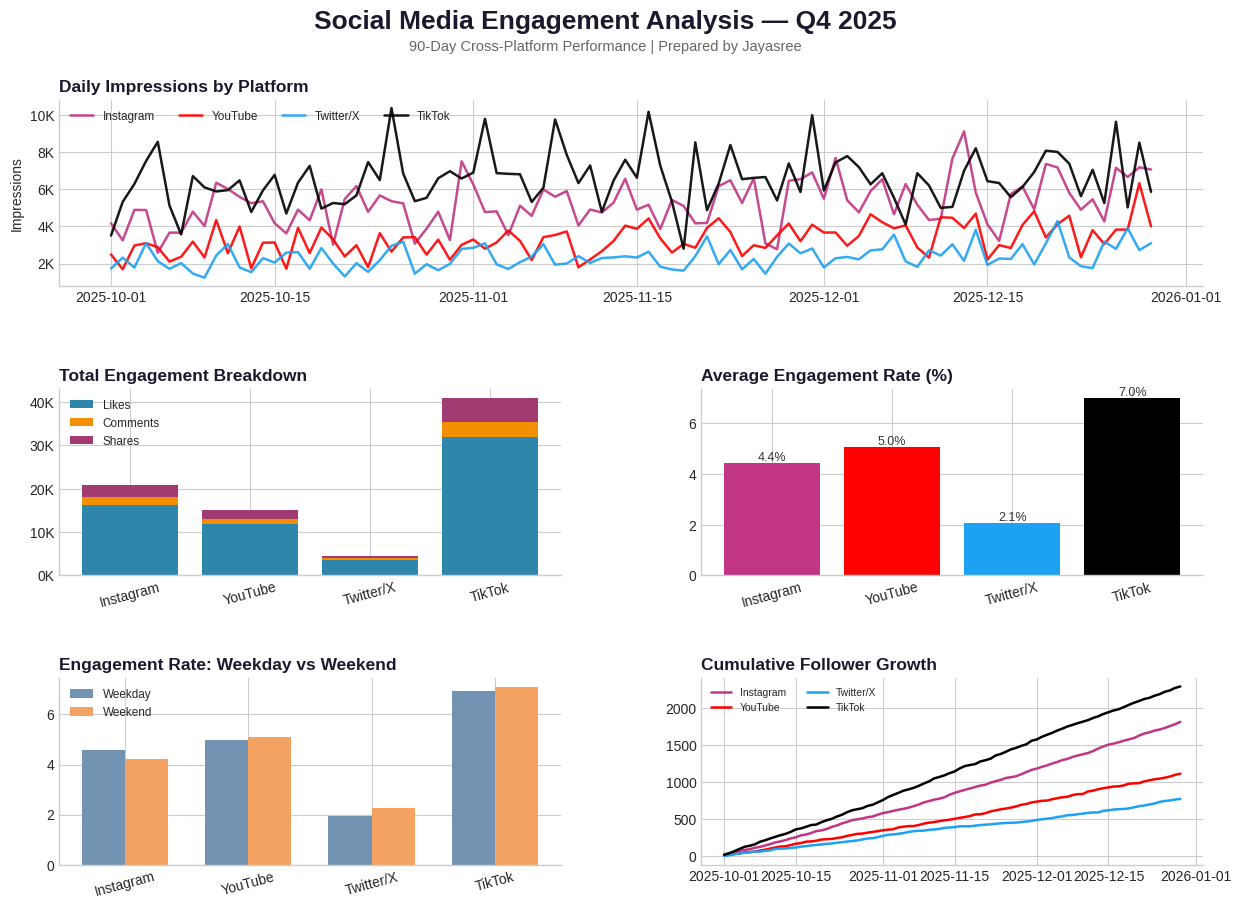

In [9]:
platforms = ["Instagram", "YouTube", "Twitter/X", "TikTok"]
colors = {"Instagram": "#C13584", "YouTube": "#FF0000", "Twitter/X": "#1DA1F2", "TikTok": "#000000"}

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(13, 9), facecolor="white")
fig.suptitle("Social Media Engagement Analysis — Q4 2025", fontsize=19, fontweight="bold", color="#1a1a2e", y=1.01)
fig.text(0.5, 0.965, "90-Day Cross-Platform Performance | Prepared by Jayasree", ha="center", fontsize=10.5, color="#666666")

gs = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.28, top=0.91, bottom=0.06, left=0.08, right=0.96)

# 1. Daily impressions trend
ax1 = fig.add_subplot(gs[0, :])
daily = df.groupby(["date", "platform"])["impressions"].sum().unstack()
for p in platforms:
    ax1.plot(daily.index, daily[p], label=p, color=colors[p], linewidth=1.8, alpha=0.9)
ax1.set_title("Daily Impressions by Platform", fontsize=12.5, fontweight="bold", color="#1a1a2e", loc="left")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax1.legend(loc="upper left", fontsize=8.5, ncol=4, frameon=False)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylabel("Impressions")

# 2. Total engagement breakdown
ax2 = fig.add_subplot(gs[1, 0])
totals = df.groupby("platform")[["likes", "comments", "shares"]].sum().loc[platforms]
bottom = np.zeros(len(platforms))
seg_colors = ["#2E86AB", "#F18F01", "#A23B72"]
for i, col in enumerate(["likes", "comments", "shares"]):
    ax2.bar(platforms, totals[col], bottom=bottom, label=col.capitalize(), color=seg_colors[i])
    bottom += totals[col].values
ax2.set_title("Total Engagement Breakdown", fontsize=12.5, fontweight="bold", color="#1a1a2e", loc="left")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax2.legend(fontsize=8.5, frameon=False)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(axis="x", rotation=15)

# 3. Engagement rate comparison
ax3 = fig.add_subplot(gs[1, 1])
avg_er = df.groupby("platform")["engagement_rate"].mean().loc[platforms] * 100
bars = ax3.bar(platforms, avg_er, color=[colors[p] for p in platforms])
ax3.set_title("Average Engagement Rate (%)", fontsize=12.5, fontweight="bold", color="#1a1a2e", loc="left")
ax3.spines[["top", "right"]].set_visible(False)
ax3.tick_params(axis="x", rotation=15)
for b in bars:
    h = b.get_height()
    ax3.text(b.get_x()+b.get_width()/2, h+0.1, f"{h:.1f}%", ha="center", fontsize=9, color="#333333")

# 4. Weekday vs weekend
ax4 = fig.add_subplot(gs[2, 0])
wk = df.groupby(["platform", "day_type"])["engagement_rate"].mean().unstack() * 100
x = np.arange(len(platforms))
width = 0.35
ax4.bar(x - width/2, wk.loc[platforms, "Weekday"], width, label="Weekday", color="#7393B3")
ax4.bar(x + width/2, wk.loc[platforms, "Weekend"], width, label="Weekend", color="#F4A261")
ax4.set_xticks(x)
ax4.set_xticklabels(platforms, rotation=15)
ax4.set_title("Engagement Rate: Weekday vs Weekend", fontsize=12.5, fontweight="bold", color="#1a1a2e", loc="left")
ax4.legend(fontsize=8.5, frameon=False)
ax4.spines[["top", "right"]].set_visible(False)

# 5. Cumulative follower growth
ax5 = fig.add_subplot(gs[2, 1])
growth = df.groupby(["date", "platform"])["new_followers"].sum().unstack().cumsum()
for p in platforms:
    ax5.plot(growth.index, growth[p], label=p, color=colors[p], linewidth=1.8)
ax5.set_title("Cumulative Follower Growth", fontsize=12.5, fontweight="bold", color="#1a1a2e", loc="left")
ax5.spines[["top", "right"]].set_visible(False)
ax5.legend(fontsize=7.5, frameon=False, loc="upper left", ncol=2)

plt.savefig("images/social_dashboard.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 7. Key Insights & Recommendations

1. **TikTok drives the strongest engagement rate (7.0%)**, more than 3x that of Twitter/X (2.1%). Prioritizing TikTok content production is likely to yield the highest return on engagement.

2. **YouTube shows the steadiest performance** across the quarter with the second-highest engagement rate (5.0%), suggesting it's a reliable channel for sustained audience interaction.

3. **Weekend posting shows minimal uplift** for most platforms, with TikTok and Twitter/X seeing slightly higher weekend engagement, while Instagram performs marginally better on weekdays. This suggests posting schedule should be platform-specific rather than uniform.

4. **TikTok and Instagram are driving the fastest follower growth**, while Twitter/X lags behind — indicating discovery-driven platforms are currently outperforming network-based ones for this account.

5. **Recommendation:** Reallocate content effort toward TikTok and YouTube, test platform-specific posting schedules instead of a single unified calendar, and investigate what's limiting Twitter/X performance (content format, posting frequency, or audience mismatch).


---
*This is a self-driven sample project using synthetically generated data to demonstrate an end-to-end data analysis workflow — from raw data cleaning to insight generation. The same process is applied to real client datasets.*